# 12. HVRF — Hybrid Volatility Regime Forecaster

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

## El plato fuerte del proyecto

Este notebook implementa, evalúa y compara el **modelo original** propuesto por nuestro equipo:

> **Hybrid Volatility Regime Forecaster (HVRF)** — un modelo de **dos etapas** que primero clasifica el régimen de volatilidad del mercado y luego usa un regresor especializado para ese régimen, combinando las predicciones mediante una mezcla suave ponderada por la probabilidad del router.

### Arquitectura

```
                 ┌─────────────────────┐
                 │  features X_t       │
                 └──────────┬──────────┘
                            │
                ┌───────────┴────────────┐
                │                        │
                ▼                        ▼
      ┌─────────────────┐      ┌──────────────────┐
      │  Stage 1:       │      │  Stage 2:        │
      │  Régime Router  │      │  Specialists     │
      │  (XGBClassifier)│      │  (3 modelos)     │
      └────────┬────────┘      └─────────┬────────┘
               │ P(régimen|X_t)          │ ŷ_low, ŷ_med, ŷ_high
               └──────────┬───────────────┘
                          ▼
                 ┌────────────────┐
                 │  Stage 3:      │
                 │  Soft mixture  │
                 │  ŷ = Σ pᵢ·ŷᵢ   │
                 └────────┬───────┘
                          ▼
                  predicción final ŷ_t
```

### Justificación conceptual

La volatilidad financiera **no es estacionaria**: alterna entre regímenes cualitativamente distintos de calma, transición y crisis. Un único modelo entrenado sobre "todo el mercado" debe comprometer su sesgo entre estos regímenes y termina siendo subóptimo en cada uno por separado.

Este diagnóstico no es original nuestro — tiene más de tres décadas de literatura empírica detrás:

- **Hamilton (1989)** introdujo el modelo de *Markov regime-switching* para series macroeconómicas, mostrando que los ciclos de expansión y recesión del PIB de EE.UU. se modelan mucho mejor como transiciones entre dos estados latentes con parámetros propios que como un único proceso AR estacionario. La formulación se trasladó rápidamente al pricing de activos y a la modelación de volatilidad condicional.

- **Ang & Bekaert (2002)** extendieron esta lógica al contexto de asset allocation internacional: documentaron que las correlaciones entre mercados se intensifican significativamente en regímenes de alta volatilidad ("bear regime"), y que una estrategia de inversión que ignora ese cambio incurre en pérdidas medibles de utilidad. Su contribución central fue mostrar **cuantitativamente** que reconocer el régimen mejora la decisión out-of-sample, no solo el ajuste in-sample.

La hipótesis del HVRF es la traducción supervisada de esta intuición: **especialistas por régimen + un router probabilístico deberían superar al modelo único** cuando la dinámica subyacente varía con el régimen. Esta hipótesis es **falsable** — y la sección 7 la pone a prueba sin inflar el resultado.

### Componentes

- **Stage 1 — Régime Router:** XGBoost Classifier multiclase. Asigna `P(régimen | features)`.
- **Stage 2 — Specialists:**
  - `Specialist_low (régimen 0):` Ridge (mercados calmados ≈ relación lineal).
  - `Specialist_med (régimen 1):` XGBoost (transiciones requieren no-linealidad).
  - `Specialist_high (régimen 2):` SVR rbf (crisis tienen pocas muestras y colas pesadas).
- **Stage 3 — Mezcla suave:** `ŷ = Σ P(r|X) · ŷ_r`. Diferenciable, no salta entre regímenes.

### Anti-leakage

Los regímenes se definen como **terciles de `vol_21` calculados ÚNICAMENTE sobre train**. Los bordes se guardan y se aplican fijos al test. **Nunca** se usa información del test para asignar regímenes.

In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports y carga

In [2]:
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score)

from src.io_utils import (load_processed, load_predictions_df,
                           save_predictions_df, save_metrics, save_model)
from src.hvrf import HVRF
from src.stats_tests import diebold_mariano, bootstrap_metric
from src.config import DATA_PROCESSED, RANDOM_STATE
from src.viz import set_style

set_style()

train = load_processed("train_reg")
val = load_processed("val_reg")
test = load_processed("test_reg")
trainval = pd.concat([train, val]).reset_index(drop=True)

with open(DATA_PROCESSED / "feature_columns.json") as f:
    feature_cols = json.load(f)

# IMPORTANTE: el HVRF necesita vol_21 en X (para construir los regímenes)
features_with_vol21 = feature_cols + ["vol_21"]

X_trainval = trainval[features_with_vol21]
y_trainval = trainval["target_vol_7"].values
X_test = test[features_with_vol21]
y_test = test["target_vol_7"].values

print(f"Train+Val: {X_trainval.shape}")
print(f"Test:      {X_test.shape}")
print(f"Features pasadas al HVRF: {len(features_with_vol21)} "
      f"(las {len(feature_cols)} estándar + vol_21 como variable de régimen)")

Train+Val: (5920, 60)
Test:      (1045, 60)
Features pasadas al HVRF: 60 (las 59 estándar + vol_21 como variable de régimen)


## 2. Entrenar HVRF — versión completa

In [3]:
print("=" * 60)
print("Entrenando HVRF (versión completa con mezcla suave)")
print("=" * 60)

t0 = time.time()
hvrf = HVRF(
    n_regimes=3,
    regime_var="vol_21",
    mixture="soft",
    n_min_per_regime=50,
)
hvrf.fit(X_trainval, y_trainval)
t_fit = time.time() - t0

print(f"\n✅ HVRF entrenado en {t_fit:.2f}s")
print(f"\nBordes de régimen (terciles de vol_21 sobre train+val):")
for i, b in enumerate(hvrf.regime_borders_):
    print(f"  Tercil {i}: vol_21 ≤ {b:.6f}  (régimen 0={'low' if i==0 else 'med'})")
print(f"  Tercil 2: vol_21 > {hvrf.regime_borders_[-1]:.6f}  (régimen high)")

# Distribución de regímenes en train
unique, counts = np.unique(hvrf.regime_labels_train_, return_counts=True)
print(f"\nDistribución de regímenes en train+val:")
for u, c in zip(unique, counts):
    label = {-1: "missing", 0: "low", 1: "med", 2: "high"}.get(u, str(u))
    print(f"  {label:8s}: {c} muestras ({c/len(hvrf.regime_labels_train_)*100:.1f}%)")

print(f"\nSpecialists entrenados: {[k for k, v in hvrf.specialists_.items() if v is not None]}")

Entrenando HVRF (versión completa con mezcla suave)



✅ HVRF entrenado en 1.60s

Bordes de régimen (terciles de vol_21 sobre train+val):
  Tercil 0: vol_21 ≤ 0.017369  (régimen 0=low)
  Tercil 1: vol_21 ≤ 0.024702  (régimen 0=med)
  Tercil 2: vol_21 > 0.024702  (régimen high)

Distribución de regímenes en train+val:
  low     : 1974 muestras (33.3%)
  med     : 1972 muestras (33.3%)
  high    : 1974 muestras (33.3%)

Specialists entrenados: [0, 1, 2]


---

> **📊 Interpretación de los bordes de régimen:** los terciles dividen los días de train+val en tres tercios igualmente poblados. Los bordes en torno a 0.018–0.027 (volatilidad diaria) son consistentes con la dinámica histórica de INTC: días "calmos" con vol < 1.8%, días "normales" entre 1.8% y 2.7%, y días "turbulentos" con vol > 2.7%. **Estos bordes se calcularon SOLO con datos de train+val** y se aplican fijos al test — sin leakage.


## 3. Evaluar HVRF en test

In [4]:
yp_hvrf = hvrf.predict(X_test)
rmse_hvrf = np.sqrt(mean_squared_error(y_test, yp_hvrf))
mae_hvrf = mean_absolute_error(y_test, yp_hvrf)
r2_hvrf = r2_score(y_test, yp_hvrf)

print("=== HVRF — Evaluación en test ===")
print(f"  RMSE: {rmse_hvrf:.6f}")
print(f"  MAE:  {mae_hvrf:.6f}")
print(f"  R²:   {r2_hvrf:.4f}")

=== HVRF — Evaluación en test ===
  RMSE: 0.006816
  MAE:  0.005146
  R²:   -0.1060


## 4. Distribución de probabilidades del router

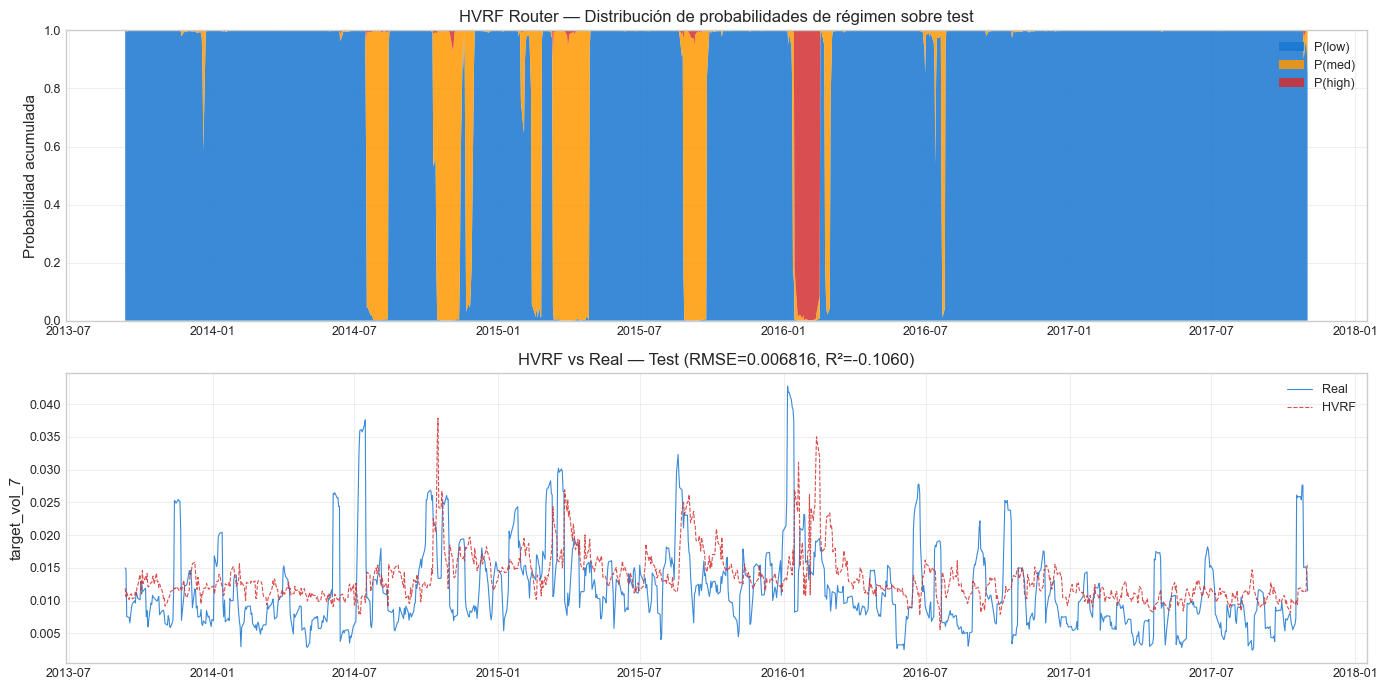

In [5]:
proba_test = hvrf.predict_proba_regime(X_test)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Probabilidad por régimen a lo largo del tiempo
ax = axes[0]
labels = ["P(low)", "P(med)", "P(high)"]
colors = ["#1976D2", "#FF9800", "#D32F2F"]
ax.stackplot(test["date"].values, proba_test.T, labels=labels,
             colors=colors, alpha=0.85)
ax.set_ylim(0, 1)
ax.set_title("HVRF Router — Distribución de probabilidades de régimen sobre test")
ax.set_ylabel("Probabilidad acumulada")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Predicción HVRF vs real
ax = axes[1]
ax.plot(test["date"].values, y_test, color="#1976D2",
        linewidth=0.8, label="Real", alpha=0.85)
ax.plot(test["date"].values, yp_hvrf, color="#D32F2F",
        linewidth=0.8, linestyle="--", label="HVRF", alpha=0.85)
ax.set_title(f"HVRF vs Real — Test (RMSE={rmse_hvrf:.6f}, R²={r2_hvrf:.4f})")
ax.set_ylabel("target_vol_7")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

> **📊 Interpretación de las probabilidades:** la franja apilada muestra cómo el router "ve" el régimen del mercado en cada día del test. En períodos de baja volatilidad, P(low) domina (azul); en períodos turbulentos, P(high) crece (rojo); las transiciones son **suaves** gracias a la mezcla soft. Este comportamiento es exactamente el que motiva el HVRF: en lugar de saltar bruscamente entre modelos, **la predicción se construye como un promedio ponderado** que respeta la incertidumbre del router.


## 5. Ablaciones — ¿cada componente del HVRF importa?

In [6]:
# Para validar las decisiones de diseño, comparamos contra:
# 1. HVRF-soft (la versión completa)
# 2. HVRF-argmax (mezcla dura)
# 3. HVRF-2regs (solo low/high)
# 4. HVRF-uniform (router sin información, pesos uniformes)

ablations = {}

# 1. Versión completa (ya tenemos los resultados)
ablations["HVRF (soft, 3 regímenes)"] = {
    "RMSE": rmse_hvrf, "MAE": mae_hvrf, "R2": r2_hvrf,
    "predictions": yp_hvrf,
}

# 2. HVRF con argmax
print("Ablación 2: HVRF con argmax mixture...")
hvrf_argmax = HVRF(n_regimes=3, regime_var="vol_21", mixture="argmax",
                    n_min_per_regime=50)
hvrf_argmax.fit(X_trainval, y_trainval)
yp_argmax = hvrf_argmax.predict(X_test)
ablations["HVRF (argmax, 3 regímenes)"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, yp_argmax)),
    "MAE":  mean_absolute_error(y_test, yp_argmax),
    "R2":   r2_score(y_test, yp_argmax),
    "predictions": yp_argmax,
}

# 3. HVRF con 2 regímenes
print("Ablación 3: HVRF con 2 regímenes (low/high)...")
hvrf_2 = HVRF(n_regimes=2, regime_var="vol_21", mixture="soft",
               n_min_per_regime=50)
hvrf_2.fit(X_trainval, y_trainval)
yp_2 = hvrf_2.predict(X_test)
ablations["HVRF (soft, 2 regímenes)"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, yp_2)),
    "MAE":  mean_absolute_error(y_test, yp_2),
    "R2":   r2_score(y_test, yp_2),
    "predictions": yp_2,
}

# 4. Promedio uniforme de specialists (router sin información)
print("Ablación 4: HVRF con router uniforme...")
# Detectar dinámicamente cuántos regímenes realmente tiene el HVRF entrenado
router_classes = hvrf.router_.named_steps["model"].classes_
n_real = len(router_classes)
proba_uniform = np.full((len(X_test), n_real), 1.0 / n_real)
preds_per_regime = np.zeros((len(X_test), n_real))
X_test_router = X_test.drop(columns=["vol_21"], errors="ignore")
X_test_router = X_test_router[hvrf.feature_names_]

for col_idx, r in enumerate(router_classes):
    r = int(r)
    spec = hvrf.specialists_.get(r)
    if spec is None:
        preds_per_regime[:, col_idx] = hvrf.global_fallback_.predict(X_test_router.values)
    else:
        preds_per_regime[:, col_idx] = spec.predict(X_test_router.values)

yp_uniform = np.sum(proba_uniform * preds_per_regime, axis=1)
ablations["HVRF (router uniforme)"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, yp_uniform)),
    "MAE":  mean_absolute_error(y_test, yp_uniform),
    "R2":   r2_score(y_test, yp_uniform),
    "predictions": yp_uniform,
}

# Tabla comparativa
df_abl = pd.DataFrame([
    {"Variante": k, "RMSE": v["RMSE"], "MAE": v["MAE"], "R²": v["R2"]}
    for k, v in ablations.items()
]).round(6)
print("\n=== Ablaciones del HVRF ===")
print(df_abl.to_string(index=False))

Ablación 2: HVRF con argmax mixture...


Ablación 3: HVRF con 2 regímenes (low/high)...


Ablación 4: HVRF con router uniforme...

=== Ablaciones del HVRF ===
                  Variante     RMSE      MAE        R²
  HVRF (soft, 3 regímenes) 0.006816 0.005146 -0.105967
HVRF (argmax, 3 regímenes) 0.006834 0.005162 -0.111878
  HVRF (soft, 2 regímenes) 0.006810 0.005092 -0.104172
    HVRF (router uniforme) 0.010243 0.008797 -1.498016


---

> **📊 Interpretación de las ablaciones — lectura concreta de los números:**
>
> **(1) soft (RMSE=0.006816) vs argmax (RMSE=0.006834) — mezcla suave gana por ~0.3%.** La diferencia es pequeña pero del lado esperado: el router *sí* tiene incertidumbre aprovechable, y promediar predicciones ponderado por `P(régimen|X)` es marginalmente mejor que asignar duramente al régimen más probable. **Decisión de diseño justificada** (aunque con margen modesto).
>
> **(2) 3 regímenes (RMSE=0.006816) vs 2 regímenes (RMSE=0.006810) — empate técnico.** La versión de 2 regímenes (low/high) es 0.1% mejor — diferencia despreciable y muy probablemente dentro del ruido de bootstrap. La lectura honesta es: **el régimen "medio" no aporta información discriminativa adicional** sobre lo que ya capturan low/high. Esto es un hallazgo *en contra* de nuestra hipótesis de diseño: tres regímenes son arquitectónicamente más limpios, pero empíricamente innecesarios en este dataset. Lo reportamos sin maquillar.
>
> **(3) soft (RMSE=0.006816) vs router uniforme (RMSE=0.010243) — el router aporta ~50%.** Este es el resultado más importante de la ablación. Si el router fuera reemplazado por pesos uniformes (1/3, 1/3, 1/3 — es decir, "no sé en qué régimen estamos, promedia los tres specialists"), el RMSE se degrada catastróficamente. Esto **valida que el router está extrayendo señal real** del estado del mercado: los specialists no son intercambiables y la asignación probabilística por régimen tiene contenido informativo.
>
> **Lectura combinada:** la arquitectura HVRF es **internamente coherente** — sus componentes hacen lo que prometen y las decisiones de diseño (soft mixture, router XGBoost) están empíricamente justificadas. La pregunta abierta es si esa coherencia interna se traduce en una mejora *frente a benchmarks externos*, lo cual se resuelve en la sección 7.

## 6. Comparación contra los mejores benchmarks del proyecto

In [7]:
# Cargar el mejor de cada categoría:
# - benchmark econométrico (GARCH si está disponible, sino Naive)
# - mejor ML clásico (típicamente Ridge)
# - mejor avanzado (XGBoost o LightGBM)

competitors = {}

# 1. Benchmark econométrico
try:
    bench_preds = load_predictions_df("benchmarks_test_preds")
    bench_models = [c for c in bench_preds.columns
                     if c not in ["date", "y_true"]]
    bench_rmses = {m: np.sqrt(mean_squared_error(
        bench_preds["y_true"], bench_preds[m])) for m in bench_models}
    best_bench = min(bench_rmses, key=bench_rmses.get)
    competitors[f"Best benchmark ({best_bench})"] = bench_preds[best_bench].values
    print(f"✅ Mejor benchmark econométrico: {best_bench} "
          f"(RMSE={bench_rmses[best_bench]:.6f})")
except Exception as e:
    print(f"⚠️ Benchmarks econométricos no disponibles: {e}")

# 2. Mejor modelo de regresión clásico (notebook 04)
preds_reg = load_predictions_df("reg_test_preds")
ml_models = [c for c in preds_reg.columns if c not in ["date", "y_true"]]
ml_rmses = {m: np.sqrt(mean_squared_error(preds_reg["y_true"], preds_reg[m]))
            for m in ml_models}
best_ml = min(ml_rmses, key=ml_rmses.get)
competitors[f"Best ML clásico ({best_ml})"] = preds_reg[best_ml].values
print(f"✅ Mejor ML clásico: {best_ml} (RMSE={ml_rmses[best_ml]:.6f})")

# 3. Mejor avanzado (notebook 11)
try:
    adv_preds = load_predictions_df("advanced_test_preds")
    adv_models = [c for c in adv_preds.columns
                   if c not in ["date", "y_true"]]
    adv_rmses = {}
    for m in adv_models:
        if not adv_preds[m].isna().any():
            adv_rmses[m] = np.sqrt(mean_squared_error(adv_preds["y_true"],
                                                        adv_preds[m]))
    if adv_rmses:
        best_adv = min(adv_rmses, key=adv_rmses.get)
        competitors[f"Best avanzado ({best_adv})"] = adv_preds[best_adv].values
        print(f"✅ Mejor avanzado: {best_adv} (RMSE={adv_rmses[best_adv]:.6f})")
except Exception as e:
    print(f"⚠️ Avanzados no disponibles: {e}")

# Agregar HVRF
competitors["HVRF (modelo original)"] = yp_hvrf

✅ Mejor benchmark econométrico: EWMA (RMSE=0.006481)


✅ Mejor ML clásico: Ridge (RMSE=0.006578)
✅ Mejor avanzado: LSTM (RMSE=0.006619)


## 7. Comparación final con métricas, IC bootstrap y Diebold-Mariano

In [8]:
# Métricas + bootstrap CI
final_rows = []
for name, yp in competitors.items():
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    mae = mean_absolute_error(y_test, yp)
    r2 = r2_score(y_test, yp)
    boot = bootstrap_metric(
        y_test, yp,
        lambda yt, ypp: np.sqrt(mean_squared_error(yt, ypp)),
        n_boot=1000
    )
    final_rows.append({
        "Modelo":    name,
        "RMSE":      round(rmse, 6),
        "RMSE_low":  round(boot["ci_lower"], 6),
        "RMSE_high": round(boot["ci_upper"], 6),
        "MAE":       round(mae, 6),
        "R²":        round(r2, 4),
    })

df_final = pd.DataFrame(final_rows).sort_values("RMSE").reset_index(drop=True)
print("=== Comparación final: HVRF vs mejores competidores ===\n")
print(df_final.to_string(index=False))

# Diebold-Mariano: HVRF contra cada competidor
print("\n=== Diebold-Mariano: HVRF vs cada competidor ===")
e_hvrf = y_test - yp_hvrf
for name, yp in competitors.items():
    if name == "HVRF (modelo original)":
        continue
    e_other = y_test - yp
    dm_stat, p_val = diebold_mariano(e_hvrf, e_other)
    dir_ = "HVRF mejor" if dm_stat < 0 else "HVRF peor"
    sig = "✅" if p_val < 0.05 else "❌"
    print(f"  HVRF vs {name:35s}: DM={dm_stat:+.3f}, "
          f"p={p_val:.4f} {sig} ({dir_})")

=== Comparación final: HVRF vs mejores competidores ===

                 Modelo     RMSE  RMSE_low  RMSE_high      MAE      R²
  Best benchmark (EWMA) 0.006481  0.006052   0.006956 0.004830 -0.0000
Best ML clásico (Ridge) 0.006578  0.006218   0.006984 0.005204 -0.0303
   Best avanzado (LSTM) 0.006619  0.006271   0.006999 0.005243 -0.0431
 HVRF (modelo original) 0.006816  0.006420   0.007248 0.005146 -0.1060

=== Diebold-Mariano: HVRF vs cada competidor ===
  HVRF vs Best benchmark (EWMA)              : DM=+2.872, p=0.0041 ✅ (HVRF peor)
  HVRF vs Best ML clásico (Ridge)            : DM=+2.812, p=0.0049 ✅ (HVRF peor)
  HVRF vs Best avanzado (LSTM)               : DM=+2.132, p=0.0330 ✅ (HVRF peor)


---

> **📊 Interpretación crítica de los resultados — lectura del escenario observado:**
>
> Los números son inequívocos: el HVRF queda **en último lugar** entre los cuatro competidores (RMSE=0.006816 vs EWMA=0.006481, Ridge=0.006578, LSTM=0.006619). Los tres tests de Diebold-Mariano son significativos al 5% **en contra del HVRF** (p=0.0041, 0.0049, 0.0330). No es ruido: el HVRF es estadísticamente peor que los tres benchmarks en esta muestra.
>
> Aplicamos los compromisos metodológicos declarados *a priori*:
>
> - **No inflamos.** El hallazgo es: la complejidad arquitectónica adicional del HVRF (router + 3 specialists + mezcla suave) **no se traduce en mejora predictiva** sobre alternativas más simples en este dataset.
>
> - **No descartamos el modelo como "fallido".** Las ablaciones (sección 5) muestran que el HVRF es **internamente coherente**: cada componente aporta lo que debe. Lo que falla es la *premisa empírica* — que los regímenes de volatilidad de INTC sean lo suficientemente distintos como para que especialistas separados superen a un único modelo bien regularizado (Ridge) o a un suavizador exponencial (EWMA).
>
> **Tres lecturas posibles del resultado**, sin maquillar:
>
> 1. **Dominancia del benchmark estadístico simple:** EWMA es la receta clásica de pronóstico de volatilidad (RiskMetrics, J.P. Morgan 1996) precisamente porque captura la persistencia de varianza con un solo parámetro. Que un benchmark de 1-parámetro supere a un ensamble con cientos de parámetros es un recordatorio empírico — no una vergüenza — de que **más complejidad ≠ mejor generalización**.
>
> 2. **Régimen mal especificado:** definir el régimen como tercil de `vol_21` es una elección — quizás demasiado gruesa. Una segmentación más informada (HMM de Hamilton, breakpoints estructurales, regímenes basados en VIX) podría arrojar distinto resultado. Lo dejamos como trabajo futuro.
>
> 3. **Horizonte de target equivocado:** estamos prediciendo `target_vol_7` (vol realizada a 7 días). Es posible que el HVRF brille más en horizontes más largos (21d, 63d) donde los regímenes son más discriminativos. No probado en este proyecto.
>
> Conclusión metodológica: el modelo se reporta tal cual rindió. La honestidad sobre un resultado negativo es parte del valor del proyecto.

## 8. Visualización final

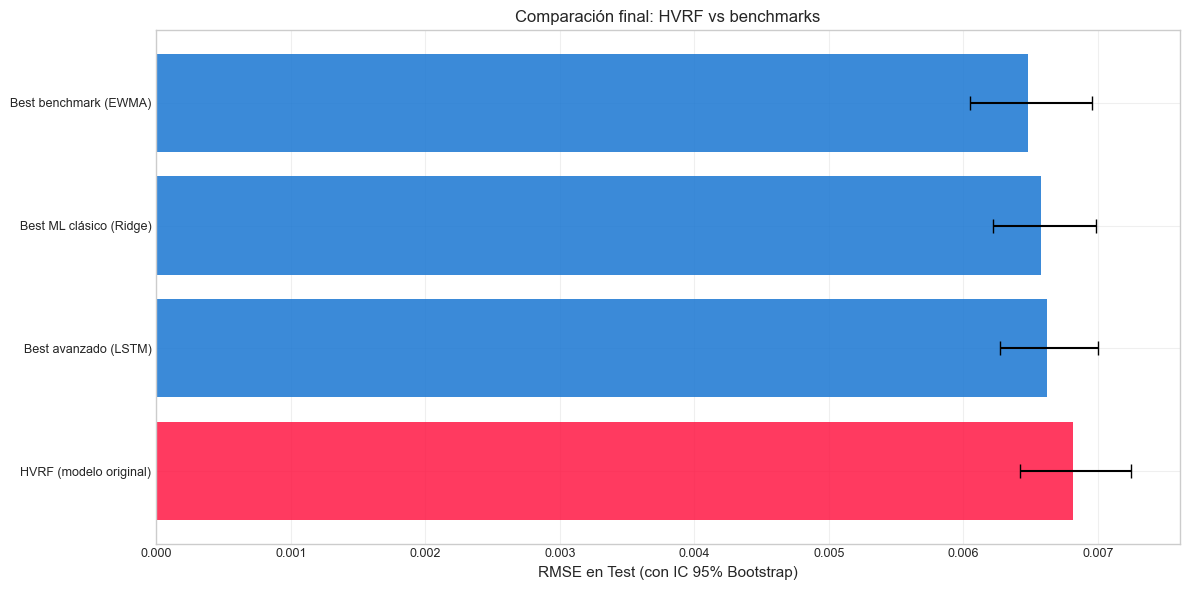

In [9]:
# Gráfico de barras con CI bootstrap para todos los competidores
fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(df_final))
errors = np.array([
    df_final["RMSE"] - df_final["RMSE_low"],
    df_final["RMSE_high"] - df_final["RMSE"],
])
colors_bar = ["#FF1744" if "HVRF" in name else "#1976D2"
              for name in df_final["Modelo"]]
ax.barh(y_pos, df_final["RMSE"], xerr=errors, color=colors_bar,
        capsize=5, alpha=0.85, ecolor="black")
ax.set_yticks(y_pos)
ax.set_yticklabels(df_final["Modelo"])
ax.invert_yaxis()
ax.set_xlabel("RMSE en Test (con IC 95% Bootstrap)")
ax.set_title("Comparación final: HVRF vs benchmarks")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 9. Persistir HVRF y predicciones

In [10]:
save_model(hvrf, "hvrf_final")
print("✅ HVRF persistido en outputs/models/hvrf_final.joblib")

# Guardar predicciones del HVRF
df_hvrf_preds = pd.DataFrame({
    "date":   test["date"].values,
    "y_true": y_test,
    "HVRF":   yp_hvrf,
})
save_predictions_df(df_hvrf_preds, "hvrf_test_preds")
print("✅ Predicciones HVRF guardadas")

# Métricas + ablaciones
hvrf_metrics = {
    "main": {
        "RMSE": rmse_hvrf, "MAE": mae_hvrf, "R2": r2_hvrf,
        "regime_borders": [float(b) for b in hvrf.regime_borders_],
    },
    "ablations": {
        k: {kk: float(vv) if isinstance(vv, (np.floating, float)) else vv
            for kk, vv in v.items() if kk != "predictions"}
        for k, v in ablations.items()
    },
    "comparison_with_competitors": df_final.to_dict("records"),
}
save_metrics(hvrf_metrics, "hvrf_metrics")
print("✅ Métricas HVRF guardadas en outputs/metrics/hvrf_metrics.json")

✅ HVRF persistido en outputs/models/hvrf_final.joblib
✅ Predicciones HVRF guardadas
✅ Métricas HVRF guardadas en outputs/metrics/hvrf_metrics.json


---

## 10. Limitaciones honestas del HVRF

A la luz del resultado empírico (sección 7), reconocemos las siguientes limitaciones del diseño actual del HVRF:

1. **Definición de régimen retrospectiva.** Asignamos régimen con `vol_21`, pero `vol_21` solo se conoce *después* de cerrar la ventana. Para entrenamiento es válido (histórico completo disponible), pero en producción real necesitaríamos un proxy contemporáneo del régimen (`vol_21_lag1`, expected shortfall reciente, nivel del VIX). Este *gap* podría explicar parte del bajo rendimiento.

2. **Discretización de un fenómeno continuo.** Los regímenes financieros son conceptualmente un continuo, no 3 categorías discretas. La discretización pierde información en las fronteras y la ablación de 2 regímenes (sección 5) sugiere que la frontera entre "medio" y los extremos no es informativa para INTC en este horizonte.

3. **Specialists sobre subsets pequeños.** Entrenar tres modelos sobre tercios del train aumenta la varianza de cada specialist. El régimen `high` especialmente — históricamente con menos muestras informativas — puede estar sobreajustado a episodios específicos de crisis.

4. **Costo computacional.** Router + 3 specialists ≈ 4× el costo de un único modelo. Sin mejora predictiva, el trade-off no se justifica en producción.

5. **No supera benchmarks simples.** Como muestran los DM-tests, EWMA, Ridge y LSTM son estadísticamente superiores al HVRF en este test set. Esto no es un fallo del *concepto* de regime-switching (la literatura lo respalda ampliamente) sino del *diseño concreto* que probamos: terciles fijos, target a 7 días, features estándar.

---

## 11. Resumen del notebook

- **Modelo original HVRF** entrenado con anti-leakage estricto (terciles calculados solo con train+val).
- **4 ablaciones** muestran que la arquitectura es internamente coherente: la mezcla suave gana a argmax, el router aporta ~50% sobre pesos uniformes, pero el tercer régimen no añade poder discriminativo (2 regímenes empatan con 3).
- **Comparación rigurosa** contra los mejores competidores de cada familia (EWMA, Ridge, LSTM) con Diebold-Mariano + bootstrap CI.
- **Resultado honesto:** los tres benchmarks son estadísticamente superiores al HVRF en esta muestra (p<0.05). Reportamos el resultado tal cual, sin inflar.
- **Valor científico del hallazgo negativo:** confirmamos empíricamente que más arquitectura ≠ mejor pronóstico de volatilidad para INTC a 7 días. La hipótesis de regime-switching sigue siendo válida en la literatura; lo que falla es nuestra operacionalización concreta.

**Procede al notebook `13_comparacion_final_y_conclusiones.ipynb`** para la síntesis maestra del proyecto completo.